#**Ejercicio Python 2: Simulación de inversión periódica (Dollar Cost Averaging)**

##Julieta Madrigal Flores

###Martes 03 de marzo 2026

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import datetime as dt

In [14]:
ticker = "AAPL"

end   = dt.datetime(2026, 2, 28)
start = end - dt.timedelta(days=365 * 4)

prices = yf.download(ticker, start=start, end=end, progress=False)["Close"]
prices = prices.dropna()
prices.tail()

/tmp/ipython-input-345/3870093263.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(ticker, start=start, end=end, progress=False)["Close"]


Ticker,AAPL
Date,
2026-02-23,266.179993
2026-02-24,272.140015
2026-02-25,274.230011
2026-02-26,272.950012
2026-02-27,264.179993


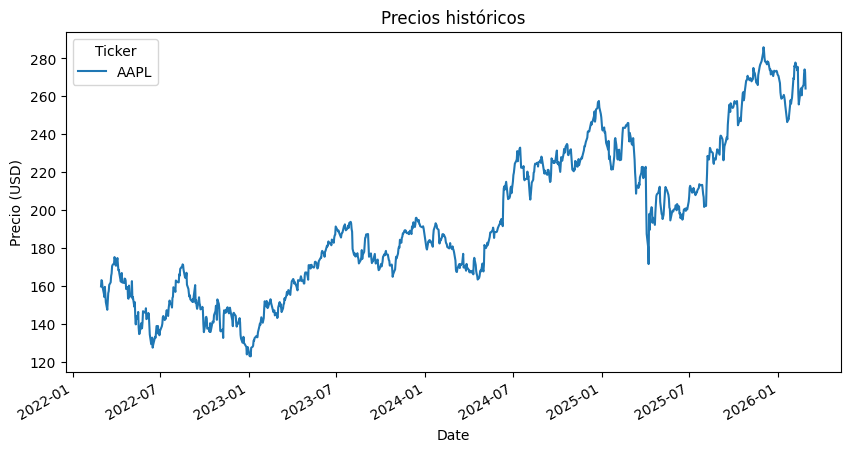

In [15]:
# Visualizar la tendencia del activo antes de simular
prices.plot(figsize=(10, 5), title="Precios históricos")
plt.ylabel("Precio (USD)")
plt.show()

In [16]:
returns = prices.pct_change().dropna()

mu    = returns.mean().values[0]
sigma = returns.std().values[0]

print("Rendimiento diario promedio:", round(mu, 6))
print("Volatilidad diaria:", round(sigma, 6))

Rendimiento diario promedio: 0.000661
Volatilidad diaria: 0.017935


In [17]:
np.random.seed(42)

monto_total = 5000
aporte_dca  = 100
n_sim = 10000
semanas = monto_total // aporte_dca   # 50 semanas
dias_semana = 5

# Cada semana tiene 5 días de trading = horizonte total es 250 días
n_days= semanas * dias_semana

In [18]:
# Simulamos 10,000 trayectorias de precios
sim_returns    = np.random.normal(mu, sigma, (n_days, n_sim))
precio_inicial = prices.values[-1][0]

# cumprod = multiplica acumuladamente los factores de crecimiento partiendo del último precio conocido
price_paths    = precio_inicial * np.cumprod(1 + sim_returns, axis=0)

# Estrategia 1: inversión única al inicio

In [19]:
# cuántas acciones puedes comprar con $5,000 al precio inicial
unidades_1    = monto_total / precio_inicial
valor_final_1 = unidades_1 * price_paths[-1]

# Estrategia 2: DCA — $100 cada semana

In [20]:
# un array vacío donde se va a guardar el valor final de cada escenario DCA
valor_dca = np.zeros(n_sim)

# Para cada escenarios se simulan las 50 compras semanales de $100
# Cada semana compras al precio que tenga AAPL en ese escenario en ese día y acumulando unidades
# finalmente multiplicas las unidades totales por el precio final de ese escenario

for s in range(n_sim):
    # Reseteas el contador de unidades a cero al inicio de cada escenario
    unidades = 0

    # Cada semana corresponde a un día específico, osea la semana 0 es el día 0, semana 1 es el día 5, semana 2 es el día 10 y así sucesivamente
    for semana in range(semanas):
        dia = semana * dias_semana

        # Cada semana inviertes $100 y compras al precio que tiene AAPL en ese día en ese escenario
        # Divides $100 entre el precio para saber cuántas fracciones de acción compras y las acumulas
        unidades += aporte_dca / price_paths[dia, s]

    # Al terminar las 50 semanas, multiplicas todas las unidades acumuladas por el precio final de AAPL en ese escenario
    # y ese es el valor final de la inversión DCA en ese escenario
    valor_dca[s] = unidades * price_paths[-1, s]

In [21]:
print("Inversión Única:")
print("  Valor final promedio:", round(np.mean(valor_final_1), 2))
print("  Desviación estándar:",  round(np.std(valor_final_1), 2))
print("  Prob. de pérdida:",     round(np.mean(valor_final_1 < monto_total), 4))

print("\nDCA:")
print("  Valor final promedio:", round(np.mean(valor_dca), 2))
print("  Desviación estándar:",  round(np.std(valor_dca), 2))
print("  Prob. de pérdida:",     round(np.mean(valor_dca < monto_total), 4))

Inversión Única:
  Valor final promedio: 5883.58
  Desviación estándar: 1691.5
  Prob. de pérdida: 0.3295

DCA:
  Valor final promedio: 5442.13
  Desviación estándar: 926.45
  Prob. de pérdida: 0.3431


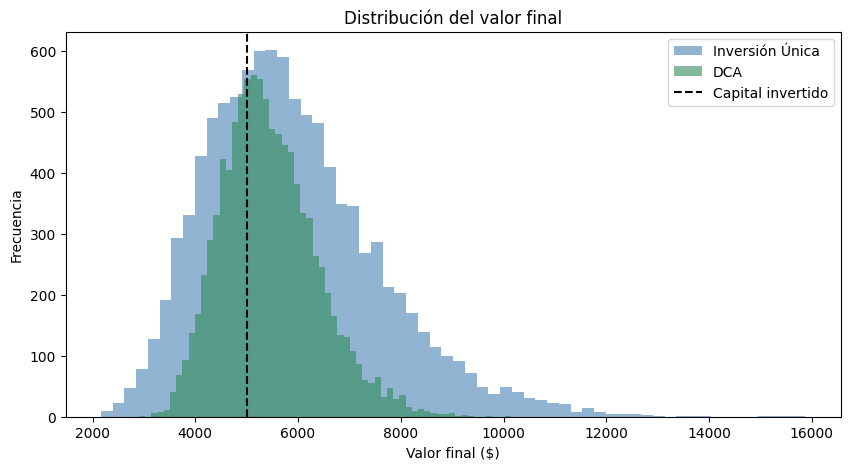

In [22]:
plt.figure(figsize=(10, 5))
plt.hist(valor_final_1, bins=60, color="steelblue", alpha=0.6, label="Inversión Única")
plt.hist(valor_dca,        bins=60, color="seagreen",  alpha=0.6, label="DCA")
plt.axvline(monto_total, color="black", linestyle="--", label="Capital invertido")
plt.xlabel("Valor final ($)")
plt.ylabel("Frecuencia")
plt.title("Distribución del valor final")
plt.legend()
plt.show()

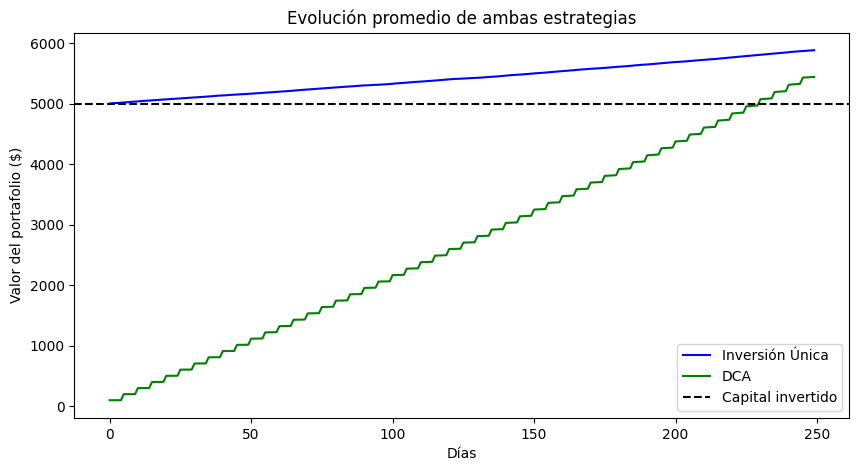

In [23]:
# inversión única = calculas el valor promedio del portafolio en cada día a lo largo de los 10,000 escenarios.
# DCA = acumulas las unidades compradas semana a semana y calculas el valor promedio del portafolio en cada día

# Multiplicar las unidades fijas de la inversión única por cada trayectoria de precios y sacas el promedio entre los 10,000 escenarios en cada día
#Esta línea  representa cómo evoluciona el valor promedio de la inversión única día a día
evolucion_unica = np.mean(unidades_1 * price_paths, axis=1)

# Creas una tabla vacía de 250 días × 10,000 escenarios donde vas a ir acumulando las unidades compradas en el DCA
unidades_acum = np.zeros((n_days, n_sim))

# Para cada una de las 50 semanas, calculas cuántas unidades compras ese día = osea $100 dividido entre el precio de ese día en cada escenario
# sumas desde ese día en adelante, osea "desde este día hasta el final" porque una vez que compras esas unidades las tienes para siempre
for semana in range(semanas):
    dia = semana * dias_semana
    unidades_acum[dia:] += aporte_dca / price_paths[dia]

# Multiplicas las unidades acumuladas por los precios de cada trayectoria y sacas el promedio entre los 10,000 escenarios en cada día
# la línea = cómo crece el valor promedio del DCA día a día
# los escalones visibles es cada vez que se hace una nueva aportación semanal
evolucion_dca = np.mean(unidades_acum * price_paths, axis=1)

# Gráfica de ambas líneas juntas para comparar cómo crece cada estrategia en el tiempo
plt.figure(figsize=(10, 5))
plt.plot(evolucion_unica, color="blue", label="Inversión Única")
plt.plot(evolucion_dca,  color="green",  label="DCA")
plt.axhline(monto_total, color="black", linestyle="--", label="Capital invertido")
plt.xlabel("Días")
plt.ylabel("Valor del portafolio ($)")
plt.title("Evolución promedio de ambas estrategias")
plt.legend()
plt.show()

##**Análisis**

| Estrategia | Valor Final Promedio | Desviación Estándar | Prob. de Pérdida |
|---|---|---|---|
| Inversión Única | $5,883.58 | $1,691.50 | 32.95% |
| DCA | $5,442.13 | $926.45 | 34.31% |

**¿Cuándo conviene DCA?**
La inversión periódica puede ser la mejor opción en mercados volátiles o que presenten tendencia bajista al inicio del periodo. En este ejercicio, el DCA tuvo una desviación estándar considerablemente menor, esto sigifica que los resultados son más predecibles y más estables. A partir de eso se puede concluir que esta estrategia es la más adecuada para un inversionista adverso al riesgo o uno que no cuente con todo el capital necesario desde el inicio.


**¿Cuándo conviene una inversión única?**
Tomando en cuenta que el mercado y el comportamiento histórico de AAPL mostraban una tendencia alcista constante durante el periodo analizado, la inversión única logra generar un valor final promedio mayor que el DCA con $5,883 pero esto también viene acompañado con mayor riesgo, la cual en este caso casi duplica el riesgo asumido en DCA. Sin embargo, al invertir todo el capital desde el primer día, se logra capturar el crecimiento completo del activo durante todo el horizonte temporal, lo cual se logra reflejar en la gráfica de evolución donde la línea azul supera constantemente al DCA desde el inicio. A partir de esto, se puede concluir que la inversión única es la más adecuada cuando el mercado muestra una tendencia alcista clara desde el inicio del periodo, como lo fue para AAPL en este ejercicio.
